# Static SHRED for NOAA data (using my methods)

Dataset: Weekly mean sea-surface temperature as given by the NOAA Optimum Interpolation SST V2 dataset [[1]](https://psl.noaa.gov/data/gridded/data.noaa.oisst.v2.html)

Model: Static SHRED from [[2]](https://royalsocietypublishing.org/rspa/article/480/2298/20240054/66770/Sensing-with-shallow-recurrent-decoder) [[3]](https://github.com/Jan-Williams/pyshred/tree/main)

In [ ]:
# Standard imports
import json
import os
import random

# Third-party imports
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from sklearn.preprocessing import MinMaxScaler

# Local imports
import models  # https://github.com/Jan-Williams/pyshred/blob/main/models.py 
from helper_functions.noaa_data import load_data
from helper_functions.plotting_functions import plot_sst_map
from helper_functions.preprocess_SHRED import (
    convert_to_anomaly,
    create_shred_sequences,
    split_ordered_data,
)
from helper_functions.saving import JsonEncoder

np.random.seed(42)
random.seed(42)

## Load data
From Mobile-Sensor SHRED paper [[4]](https://ieeexplore.ieee.org/document/10584544):

- Weekly mean SST from 1992 - 2019
- 1400 snapshots of a 180 x 360 grid, with landmass excluded leaves 44,219 spatial locations corresponding to the sea surface

In [2]:
data, lats, longs, dates = load_data()
print(data.shape, len(longs), len(lats))

(1400, 44219) 44219 44219


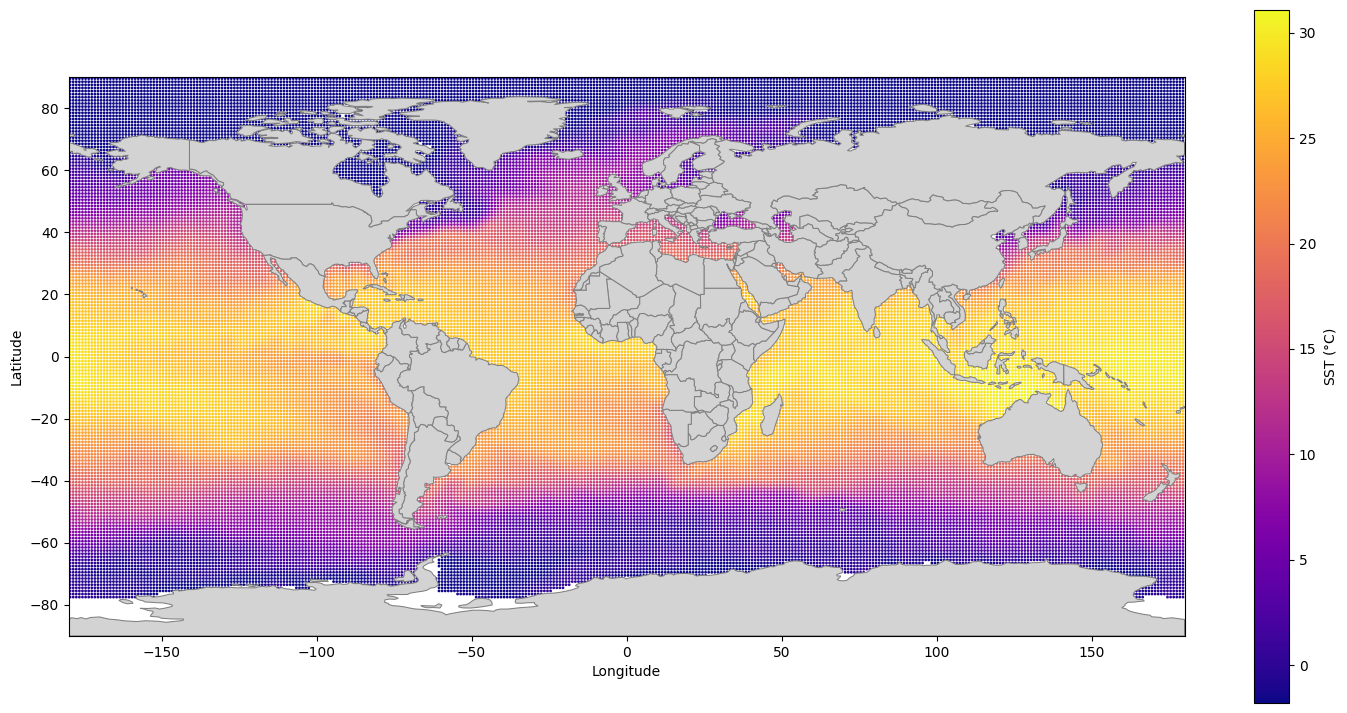

In [3]:
df = pd.DataFrame({"Longitude": longs, "Latitude": lats, "SST": data[0]})
plot_sst_map(df)

In [4]:
exp_name = "NOAA/SDN"
model_type = "SDN"
num_sensors = 3
lags = 52
hidden_dim = 64
sequence_model = "LSTM"
anomaly = False

## SHRED preprocessing

In [5]:
print("Preprocessing data...")
train_data, val_data, test_data, train_dates, val_dates, test_dates = split_ordered_data(data, dates, all_dates=True)
if anomaly:
    train_anomaly, val_anomaly, test_anomaly, bulk_mean = convert_to_anomaly((train_data, val_data, test_data))

Preprocessing data...


In [6]:
print(train_data.shape)
print(val_data.shape)
print(test_data.shape)
print(len(train_data)+len(test_data)+len(val_data))

(1050, 44219)
(175, 44219)
(175, 44219)
1400


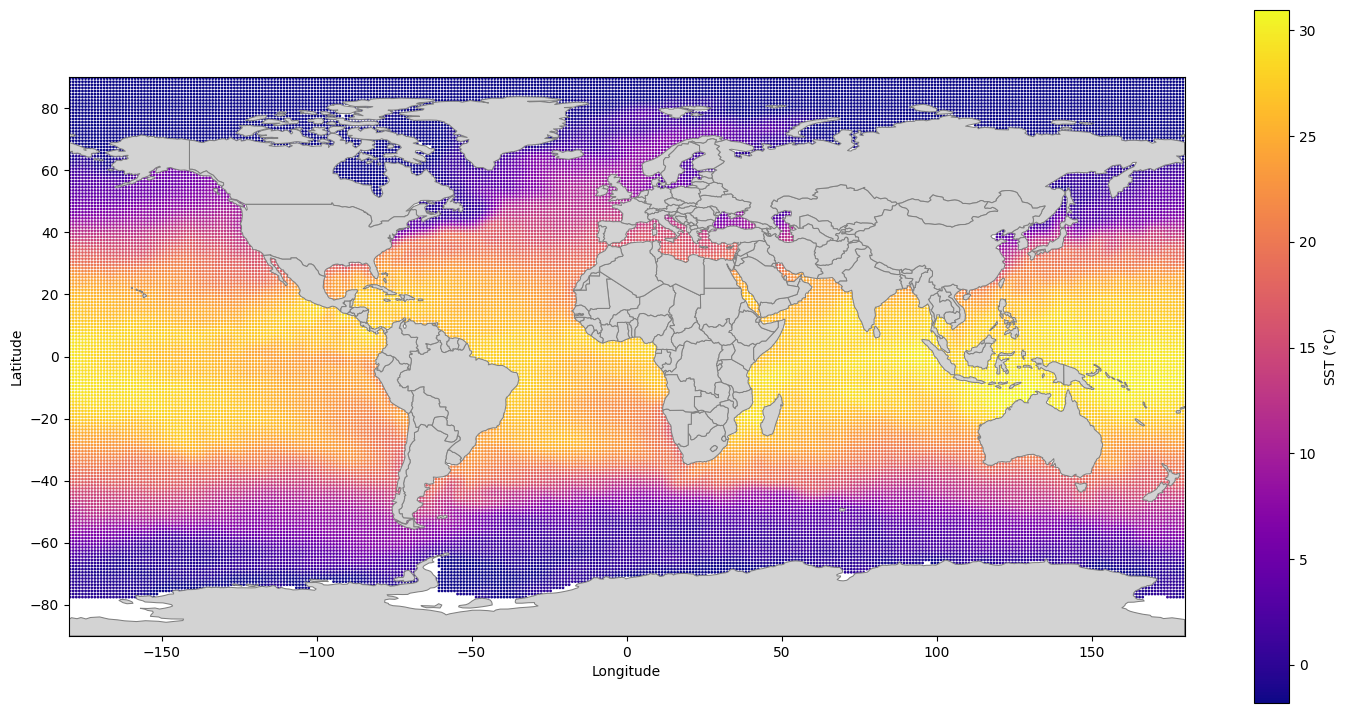

In [8]:
df = pd.DataFrame({"Longitude": longs, "Latitude": lats, "SST": data[1]})
plot_sst_map(df)

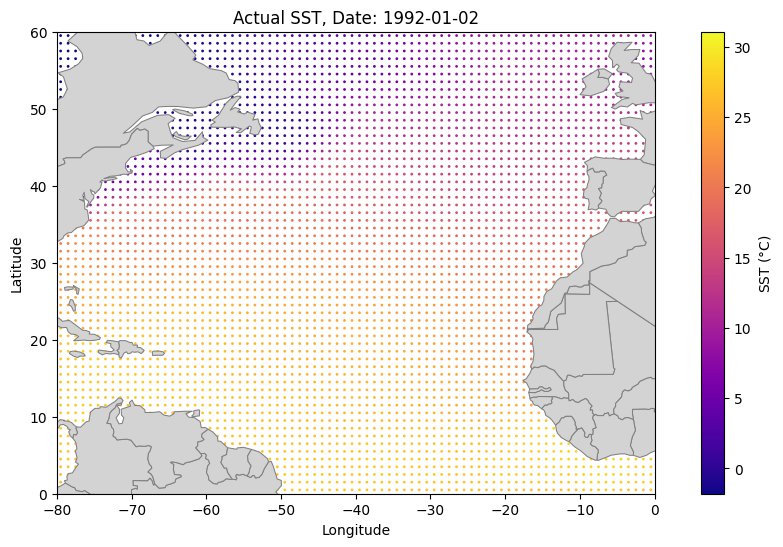

In [9]:
# Plots for santity checks:
plot_index = 0
sst_df = pd.DataFrame({
    "Longitude": longs,
    "Latitude": lats,
    "SST": train_data[plot_index]
})
plot_sst_map(sst_df, area="NA", cmap="plasma", title=f"Actual SST, Date: {train_dates[plot_index]}")

if anomaly:
    anomaly_df = pd.DataFrame({
        "Longitude": longs,
        "Latitude": lats,
        "SST": train_anomaly[plot_index]
    })
    plot_sst_map(anomaly_df, area="NA", cmap="viridis", title=f"SST Anomaly, Date: {train_dates[plot_index]}")

    bulk_df = pd.DataFrame({
        "Longitude": longs,
        "Latitude": lats,
        "SST": bulk_mean
    })
    plot_sst_map(bulk_df, area="NA", cmap="plasma", title=f"Bulk mean SST, Dates: {train_dates[0]} to {train_dates[-1]}")

In [10]:
# Normalise data
if anomaly:
    sc = MinMaxScaler()
    sc = sc.fit(train_anomaly)  # Computes min and max from training data only (prevent data leakage)
    train_transformed = sc.transform(train_anomaly)  
    val_transformed = sc.transform(val_anomaly)
    test_transformed = sc.transform(test_anomaly)
else:
    sc = MinMaxScaler()
    sc = sc.fit(train_data)  # Computes min and max from training data only (prevent data leakage)
    train_transformed = sc.transform(train_data)  
    val_transformed = sc.transform(val_data)
    test_transformed = sc.transform(test_data)

# Build sequences
sensor_locations = np.random.choice(data.shape[1], size=num_sensors, replace=False)
sensor_coords=(longs[sensor_locations], lats[sensor_locations])
print(f"Sensor location indexes will be: {sensor_locations}")

# Build sequences
train_dataset = create_shred_sequences(train_transformed, sensor_locations, lags=lags)
val_dataset = create_shred_sequences(val_transformed, sensor_locations, lags=lags)
test_dataset = create_shred_sequences(test_transformed, sensor_locations, lags=lags)

# Get dates corresponding to the predictions made by the model
train_lag_dates = train_dates[np.array(range(len(train_dates)-lags)) + lags - 1]
val_lag_dates = val_dates[np.array(range(len(val_dates)-lags)) + lags - 1]
test_lag_dates = test_dates[np.array(range(len(test_dates)-lags)) + lags - 1]

Sensor location indexes will be: [28619  6515 13648]


In [12]:
print(len(train_dataset))
print(len(val_dataset))
print(len(test_dataset))
print(len(train_dataset) + len(val_dataset) + len(test_dataset))

998
123
123
1244


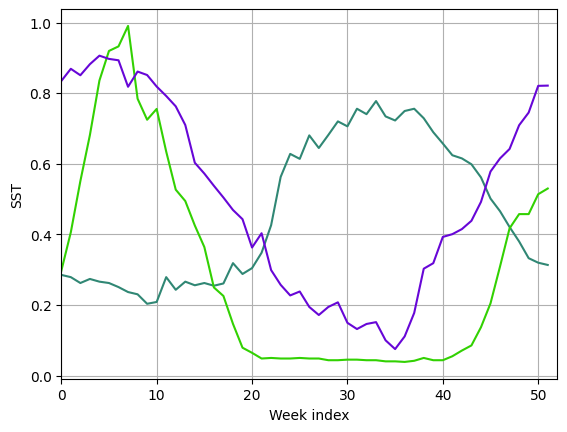

In [13]:
plot_index = 3
plot_data = test_dataset[plot_index]
random_colours = ["#"+''.join([random.choice('0123456789ABCDEF') for j in range(6)])
            for i in range(num_sensors)]

for i in range(num_sensors):
    # plot_data[0] -> test sequences
    # plot_data[0].T -> for each sensor, timeseries of SST values across test dataset
    plt.plot(plot_data[0].T[i], c=random_colours[i])
plt.ylabel("SST")
plt.xlabel("Week index")
plt.grid()
plt.xlim(0, 52)
plt.show()

## Train + test SHRED model

In [14]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

if model_type == "SHRED":
    model = models.SHRED(num_sensors, len(lats), seq_model=sequence_model, hidden_size=hidden_dim,
                        hidden_layers=2, l1=350, l2=400, dropout=0.1).to(device)
elif model_type == "SDN":
    model = models.SDN(num_sensors, len(lats), l1=350, l2=400, dropout=0.1).to(device)

validation_errors = models.fit(model, train_dataset, val_dataset, batch_size=64, num_epochs=1000, lr=1e-3, verbose=True, patience=5)

torch.Size([64, 52, 44219])
64


/Users/zz25874/Documents/foundation_year/Summer project/ME4OH_summer_project/.venv/lib/python3.14/site-packages/torch/nn/modules/loss.py:626: UserWarning: Using a target size (torch.Size([64, 44219])) that is different to the input size (torch.Size([64, 52, 44219])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


RuntimeError: The size of tensor a (52) must match the size of tensor b (64) at non-singleton dimension 1

In [ ]:
test_recons = sc.inverse_transform(model(test_dataset.X).detach().cpu().numpy())
test_ground_truth = sc.inverse_transform(test_dataset.Y.detach().cpu().numpy())
print('Test Reconstruction Error: ')
print(np.linalg.norm(test_recons - test_ground_truth) / np.linalg.norm(test_ground_truth))

## Save results

In [ ]:
# Make experiment folder
directory = f"Reconstructions/Static/{exp_name}/"
os.makedirs(directory, exist_ok = True)

In [ ]:
np.save(f"Reconstructions/Static/{exp_name}/recons_n{num_sensors}_l{lags}", test_recons)
np.save(f"Reconstructions/Static/{exp_name}/truth_n{num_sensors}_l{lags}", test_ground_truth)

In [ ]:
metadata = {
    "sensor_locations": list(sensor_locations),
    "sensor_coords": list(sensor_coords),
    "test_lag_dates": list(test_lag_dates)
    }

if anomaly:
    metadata["bulk_mean"] = bulk_mean

In [ ]:
with open(f"Reconstructions/Static/{exp_name}/metadata_n{num_sensors}_l{lags}.json", 'w', encoding='utf-8') as f:
    json.dump(metadata, f, cls=JsonEncoder)